# Notebook 03 - Red neuronal convolucional (CNN)

En este notebook implementamos una CNN 1D para clasificar actividades humanas usando las señales crudas de los sensores.

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
print('Listo')

Listo


## 2. Carga de Datos Secuenciales

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_seq.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val_seq.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_seq.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Datos cargados:')
print('  Train:', X_tr.shape)
print('  Validation:', X_val.shape)
print('  Test:', X_test.shape)
print('  Formato: (muestras, 128 pasos de tiempo, 9 canales)')

Datos cargados:
  Train: (5881, 128, 9)
  Validation: (1471, 128, 9)
  Test: (2947, 128, 9)
  Formato: (muestras, 128 pasos de tiempo, 9 canales)


## 3. Arquitectura CNN 1D

Las CNN 1D aplican filtros convolucionales a lo largo del eje del tiempo. Cada filtro detecta un patrón local (como una oscilación o un pico) en la señal del sensor. Esto es muy efectivo para datos de series de tiempo porque:

- Los **patrones locales** en las señales son informativos (una oscilación rítmica indica caminar).
- La **invarianza traslacional** permite detectar el mismo patrón en cualquier parte de la señal.
- El **pooling** reduce la dimensionalidad y hace la red más robusta al ruido.

In [3]:
modelo_cnn = Sequential([
    # Primera capa convolucional
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(128, 9)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Segunda capa convolucional
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Tercera capa convolucional
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Dropout(0.2),

    # Aplanar para conectar con capa densa
    Flatten(),

    # Capa densa
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Salida
    Dense(6, activation='softmax')
])

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,182 (1.08 MB)

 Trainable params: 281,798 (1.07 MB)

 Non-trainable params: 384 (1.50 KB)

Usamos:
- **Conv1D**: aplica filtros de tamaño 3 sobre la dimensión temporal. Detecta patrones en 3 pasos de tiempo consecutivos.
- **MaxPooling1D**: reduce la dimensión temporal tomando el valor máximo en ventanas de 2 pasos. Esto hace la representación más compacta.
- **Flatten**: convierte el tensor 2D en un vector 1D para las capas densas finales.

## 4. Entrenamiento

In [4]:
modelo_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inicio = time.time()

historial = modelo_cnn.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7757 - loss: 0.5783 - val_accuracy: 0.3372 - val_loss: 1.3904
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9223 - loss: 0.1912 - val_accuracy: 0.5167 - val_loss: 1.1007
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9398 - loss: 0.1448 - val_accuracy: 0.8511 - val_loss: 0.4402
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9458 - loss: 0.1258 - val_accuracy: 0.9429 - val_loss: 0.1685
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9497 - loss: 0.1132 - val_accuracy: 0.9531 - val_loss: 0.1188
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9480 - loss: 0.1143 - val_accuracy: 0.9531 - val_loss: 0.1146
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9473 - loss: 0.1178 - val_accuracy: 0.9545 - val_loss: 0.0925
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9490 - loss: 0.1049 - val_accuracy: 0.9599 - v

## 5. Curvas de aprendizaje

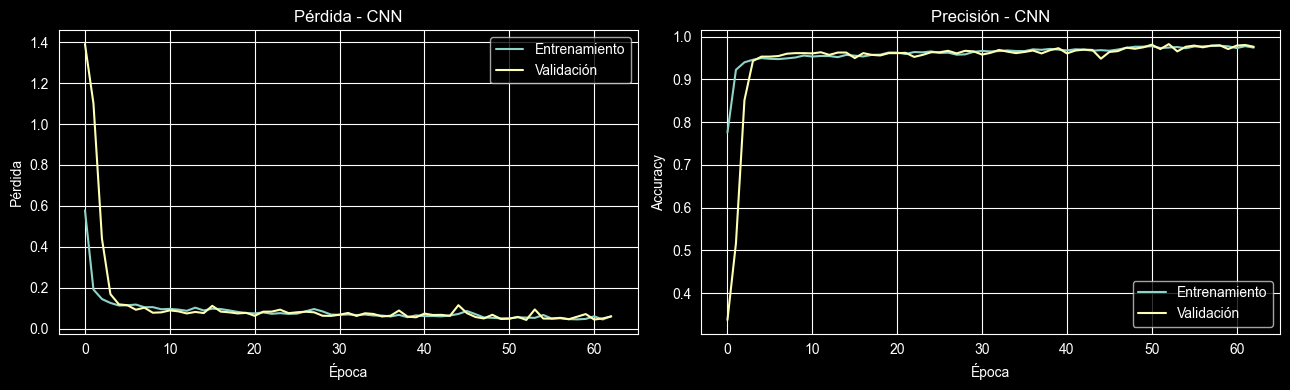

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - CNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - CNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/curvas_cnn.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Evaluación

In [6]:
y_pred_prob = modelo_cnn.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print('Reporte de Clasificación:')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step
Accuracy en Test: 0.9267

Reporte de Clasificación:
                    precision    recall  f1-score   support

           WALKING       0.98      1.00      0.99       496
  WALKING_UPSTAIRS       0.97      0.97      0.97       471
WALKING_DOWNSTAIRS       0.98      0.95      0.96       420
           SITTING       0.84      0.77      0.81       491
          STANDING       0.83      0.87      0.85       532
            LAYING       0.97      1.00      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



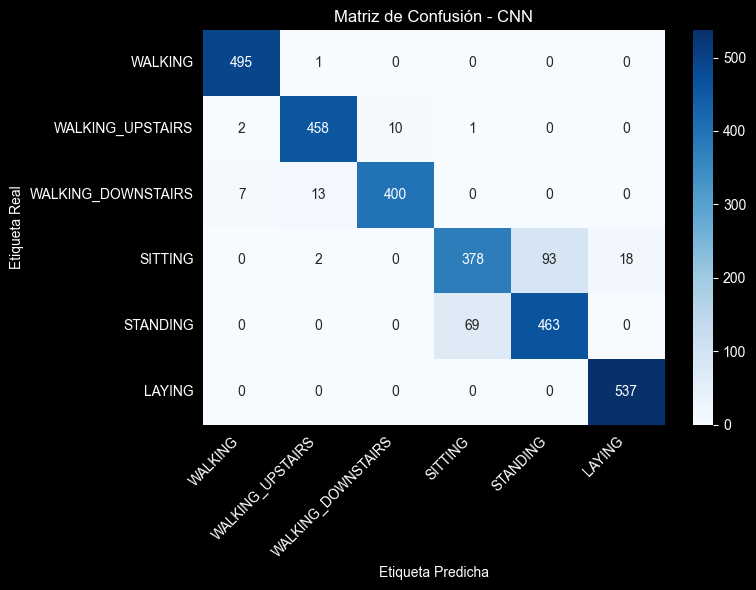

In [7]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - CNN')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_cnn.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
metricas_cnn = {
    'modelo': 'CNN',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

for k, v in metricas_cnn.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open('../models/metricas_cnn.json', 'w') as f:
    json.dump(metricas_cnn, f)

modelo_cnn.save('../models/modelo_cnn.keras')
print('\nMétricas y modelo guardados.')

  modelo: CNN
  accuracy: 0.9267
  precision: 0.9260
  recall: 0.9267
  f1: 0.9259
  tiempo_entrenamiento: 338.3148

Métricas y modelo guardados.


## 7. Casos de prueba individuales

In [9]:
indices_muestra = np.random.choice(len(X_test), 5, replace=False)

print('Casos de prueba individuales:')
print(f'{"Índice":<8} {"Real":<25} {"Predicho":<25} {"Confianza":<10} {"Correcto"}')
print('-' * 80)
for idx in indices_muestra:
    real = nombres_clases[y_test_int[idx]]
    pred = nombres_clases[y_pred_int[idx]]
    confianza = y_pred_prob[idx].max()
    correcto = '✓' if real == pred else '✗'
    print(f'{idx:<8} {real:<25} {pred:<25} {confianza:<10.3f} {correcto}')

Casos de prueba individuales:
Índice   Real                      Predicho                  Confianza  Correcto
--------------------------------------------------------------------------------
565      WALKING                   WALKING                   1.000      ✓
1220     STANDING                  STANDING                  0.673      ✓
1677     WALKING_UPSTAIRS          WALKING_UPSTAIRS          1.000      ✓
1577     LAYING                    LAYING                    1.000      ✓
2834     LAYING                    LAYING                    1.000      ✓


## Conclusiones del modelo CNN

**Ventajas de la CNN para datos de sensores:**
- Detecta patrones locales en la señal temporal (ejemplo: el patrón de oscilación al caminar).
- Tiene menos parámetros que un MLP equivalente gracias al uso compartido de pesos.
- El pooling hace el modelo más robusto frente a variaciones temporales pequeñas.

**Limitaciones:**
- Las CNN no capturan dependencias a largo plazo en la secuencia; solo ven ventanas locales.
- Para actividades que dependen de secuencias largas de movimiento, los modelos recurrentes pueden ser más adecuados.

En general, la CNN supera al MLP porque trabaja directamente con las señales crudas y puede aprender características relevantes sin necesidad de ingeniería manual de características.